# Exploratory Data Analysis: Supply Chain Demand Insights

## Objective

The objective of this notebook is to analyze demand patterns across selected stores and product families in the grocery retail network.

This notebook focuses on:

- Overall demand performance
- Product family demand
- Store-level demand
- Monthly and daily demand trends
- Holiday and promotion effects
- Fast-moving and slow-moving product categories
- Demand variability across stores and product families

The insights from this notebook will support demand forecasting, inventory optimization, and Power BI dashboard development.

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### The libraries were imported for data analysis and visualization. Pandas is used for working with tables, NumPy supports numerical operations, and Matplotlib is used to create charts.

### Loading the final master dataset

In [2]:
folder = r"C:\Users\DEBIDO\Desktop\favorita-grocery-sales-forecasting"

master = pd.read_csv(folder + r"\final_master_dataset.csv")

In [3]:
master.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,state,type,cluster,transactions,dcoilwtico,is_holiday
0,66458908,2016-01-01,25,105574,12.0,False,GROCERY I,1045,0,Salinas,Santa Elena,D,1,0.0,36.81,True
1,66458909,2016-01-01,25,105575,9.0,False,GROCERY I,1045,0,Salinas,Santa Elena,D,1,0.0,36.81,True
2,66458910,2016-01-01,25,105857,3.0,False,GROCERY I,1092,0,Salinas,Santa Elena,D,1,0.0,36.81,True
3,66458911,2016-01-01,25,108634,3.0,False,GROCERY I,1075,0,Salinas,Santa Elena,D,1,0.0,36.81,True
4,66458913,2016-01-01,25,108786,2.0,False,CLEANING,3044,0,Salinas,Santa Elena,D,1,0.0,36.81,True


##### The final master dataset created in Notebook 2 was loaded. This dataset already contains sales, product details, store details, transaction volume, oil prices, and holiday information.

In [4]:
master.shape

(5922347, 16)

### Checking column names

In [5]:
master.columns.tolist()

['id',
 'date',
 'store_nbr',
 'item_nbr',
 'unit_sales',
 'onpromotion',
 'family',
 'class',
 'perishable',
 'city',
 'state',
 'type',
 'cluster',
 'transactions',
 'dcoilwtico',
 'is_holiday']

### Checking data types

In [6]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5922347 entries, 0 to 5922346
Data columns (total 16 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            int64  
 1   date          object 
 2   store_nbr     int64  
 3   item_nbr      int64  
 4   unit_sales    float64
 5   onpromotion   bool   
 6   family        object 
 7   class         int64  
 8   perishable    int64  
 9   city          object 
 10  state         object 
 11  type          object 
 12  cluster       int64  
 13  transactions  float64
 14  dcoilwtico    float64
 15  is_holiday    bool   
dtypes: bool(2), float64(3), int64(6), object(5)
memory usage: 643.9+ MB


##### The data types were checked to confirm whether each column is stored correctly. The date column may need to be converted back to datetime after loading the CSV file.

### Convert date column

In [7]:
master["date"] = pd.to_datetime(master["date"])

In [8]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5922347 entries, 0 to 5922346
Data columns (total 16 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   item_nbr      int64         
 4   unit_sales    float64       
 5   onpromotion   bool          
 6   family        object        
 7   class         int64         
 8   perishable    int64         
 9   city          object        
 10  state         object        
 11  type          object        
 12  cluster       int64         
 13  transactions  float64       
 14  dcoilwtico    float64       
 15  is_holiday    bool          
dtypes: bool(2), datetime64[ns](1), float64(3), int64(6), object(4)
memory usage: 643.9+ MB


##### The date column was converted to datetime format so that time-based analysis can be performed correctly.

### Creating date features

In [9]:
master["year"] = master["date"].dt.year
master["month"] = master["date"].dt.month
master["month_name"] = master["date"].dt.month_name()
master["day_of_week"] = master["date"].dt.day_name()
master["is_weekend"] = master["day_of_week"].isin(["Saturday", "Sunday"])

In [10]:
## To confirm if the columns have been added
master.columns.tolist()

['id',
 'date',
 'store_nbr',
 'item_nbr',
 'unit_sales',
 'onpromotion',
 'family',
 'class',
 'perishable',
 'city',
 'state',
 'type',
 'cluster',
 'transactions',
 'dcoilwtico',
 'is_holiday',
 'year',
 'month',
 'month_name',
 'day_of_week',
 'is_weekend']

##### New date features were created to support monthly, weekly, and day-of-week demand analysis.

### Checking for missing values

In [11]:
master.isnull().sum()

id              0
date            0
store_nbr       0
item_nbr        0
unit_sales      0
onpromotion     0
family          0
class           0
perishable      0
city            0
state           0
type            0
cluster         0
transactions    0
dcoilwtico      0
is_holiday      0
year            0
month           0
month_name      0
day_of_week     0
is_weekend      0
dtype: int64

##### Missing values were checked to confirm that the final dataset is clean before analysis.

### Summary of key numeric columns

In [12]:
master[["unit_sales", "transactions", "dcoilwtico"]].describe()

,unit_sales,transactions,dcoilwtico
count,5.922347e+06,5.922347e+06,5.922347e+06
mean,1.506335e+01,3.430187e+03,4.577773e+01
std,3.432166e+01,1.193753e+03,6.347789e+00
min,1.400000e-02,0.000000e+00,2.619000e+01
25%,3.000000e+00,2.981000e+03,4.341000e+01
50%,7.000000e+00,3.540000e+03,4.724000e+01
75%,1.600000e+01,4.186000e+03,4.985000e+01
max,2.074800e+04,8.307000e+03,5.448000e+01


##### The main numeric columns were summarized. Unit sales represent demand, transactions represent store activity, and oil price is included as an external economic variable.

### Overall business KPIs

In [13]:
total_demand = master["unit_sales"].sum()
average_daily_demand = master.groupby("date")["unit_sales"].sum().mean()
number_of_stores = master["store_nbr"].nunique()
number_of_families = master["family"].nunique()
number_of_items = master["item_nbr"].nunique()

unique_store_day_transactions = master[
    ["date", "store_nbr", "transactions"]
].drop_duplicates()

total_transactions = unique_store_day_transactions["transactions"].sum()

print("Total Demand:", round(total_demand, 2))
print("Average Daily Demand:", round(average_daily_demand, 2))
print("Number of Stores:", number_of_stores)
print("Number of Product Families:", number_of_families)
print("Number of Items:", number_of_items)
print("Total Transactions:", round(total_transactions, 2))

Total Demand: 89210385.57
Average Daily Demand: 150693.22
Number of Stores: 5
Number of Product Families: 8
Number of Items: 2897
Total Transactions: 9347180.0


The transactions column is repeated across multiple product rows after merging. To avoid double-counting, total transactions were calculated using unique store-date transaction records.

### Total demand by product family

In [14]:
family_demand = master.groupby("family")["unit_sales"].sum().sort_values(ascending=False)

family_demand

family
GROCERY I       2.542437e+07
BEVERAGES       2.261576e+07
PRODUCE         1.962363e+07
DAIRY           6.407897e+06
CLEANING        6.033051e+06
BREAD/BAKERY    3.482735e+06
POULTRY         3.111344e+06
MEATS           2.511597e+06
Name: unit_sales, dtype: float64

Total demand was grouped by product family to identify which product categories contribute the highest sales volume. and the `GROCERY I` category contributed the highest sales volume.

### Demand by product family

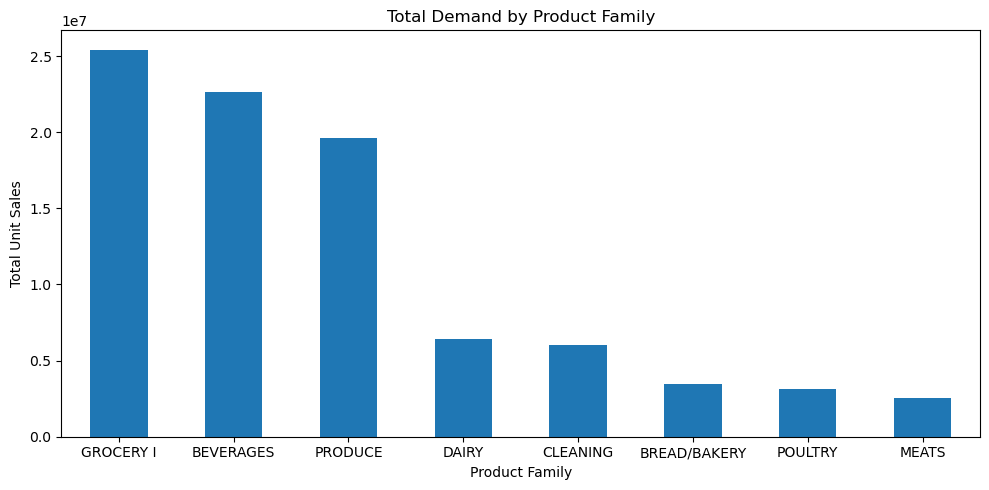

In [52]:
plt.figure(figsize=(10, 5))
family_demand.plot(kind="bar")
plt.title("Total Demand by Product Family")
plt.xlabel("Product Family")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart shows that `GROCERY I` is the highest-demand product family.

### Demand share by product family

In [16]:
family_share = (family_demand / family_demand.sum()) * 100

family_share.round(2)

family
GROCERY I       28.50
BEVERAGES       25.35
PRODUCE         22.00
DAIRY            7.18
CLEANING         6.76
BREAD/BAKERY     3.90
POULTRY          3.49
MEATS            2.82
Name: unit_sales, dtype: float64

##### The demand share shows the percentage contribution of each product family to total demand. This helps identify that `GROCERY I ` categories are most important to the business.

In [51]:
top_3_family_share = family_share.head(3).sum()

print("Top 3 product families contribute:", round(top_3_family_share, 2), "% of total demand")

Top 3 product families contribute: 75.85 % of total demand


The top three product families — GROCERY I, BEVERAGES, and PRODUCE — contribute 75.85% of total demand. This shows that a small number of categories drive most sales volume, so these categories should receive priority in demand forecasting and replenishment planning.

### Total demand by store

In [17]:
store_demand = master.groupby("store_nbr")["unit_sales"].sum().sort_values(ascending=False)

store_demand

store_nbr
44    2.411947e+07
45    2.172711e+07
47    2.013586e+07
49    1.902923e+07
25    4.198712e+06
Name: unit_sales, dtype: float64

##### Total demand was grouped by store to compare sales performance across the selected retail locations.

### Demand by store

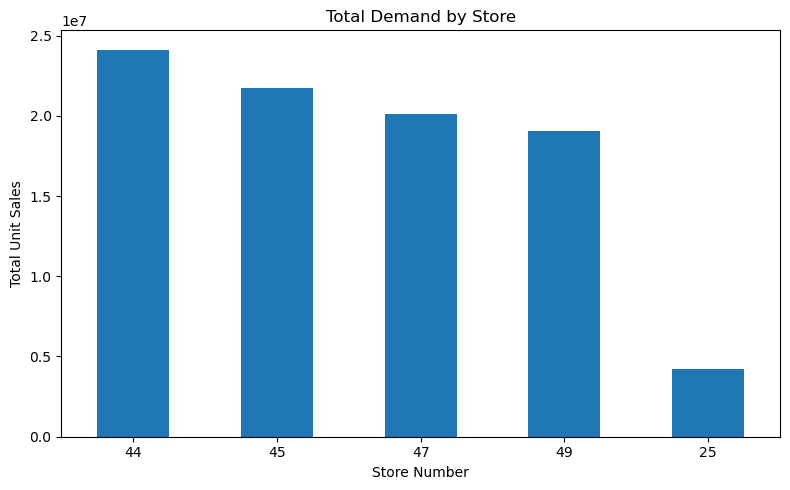

In [18]:
plt.figure(figsize=(8, 5))
store_demand.plot(kind="bar")
plt.title("Total Demand by Store")
plt.xlabel("Store Number")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### The store demand chart shows that ` Stores 44 ` generate the highest sales volume. High-demand stores may require stronger replenishment planning and closer monitoring.

### Monthly demand trend

In [19]:
monthly_demand = master.groupby(["year", "month"])["unit_sales"].sum().reset_index()

monthly_demand["year_month"] = (
    monthly_demand["year"].astype(str) + "-" + monthly_demand["month"].astype(str).str.zfill(2)
)

monthly_demand.head()

,year,month,unit_sales,year_month
0,2016,1,4566029.869,2016-01
1,2016,2,4170308.472,2016-02
2,2016,3,4360675.294,2016-03
3,2016,4,4816703.763,2016-04
4,2016,5,4412461.171,2016-05


##### Demand was aggregated by month to identify broader demand trends over time.

### Monthly demand trend

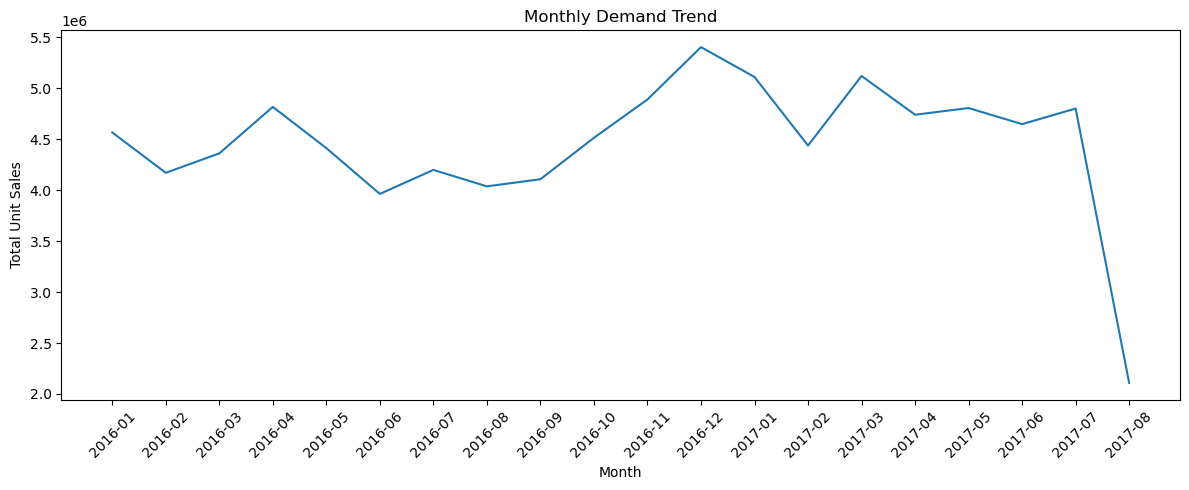

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_demand["year_month"], monthly_demand["unit_sales"])
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### The monthly trend chart helps identify whether demand increased, decreased, or fluctuated over the selected analysis period.

### Daily demand trend

In [21]:
daily_demand = master.groupby("date")["unit_sales"].sum().reset_index()

daily_demand.head()

,date,unit_sales
0,2016-01-01,13842.389
1,2016-01-02,215628.642
2,2016-01-03,251286.615
3,2016-01-04,182353.718
4,2016-01-05,148223.454


##### Demand was aggregated at the daily level to show the movement of total demand over time. This daily dataset can also support forecasting later.

### Daily demand trend

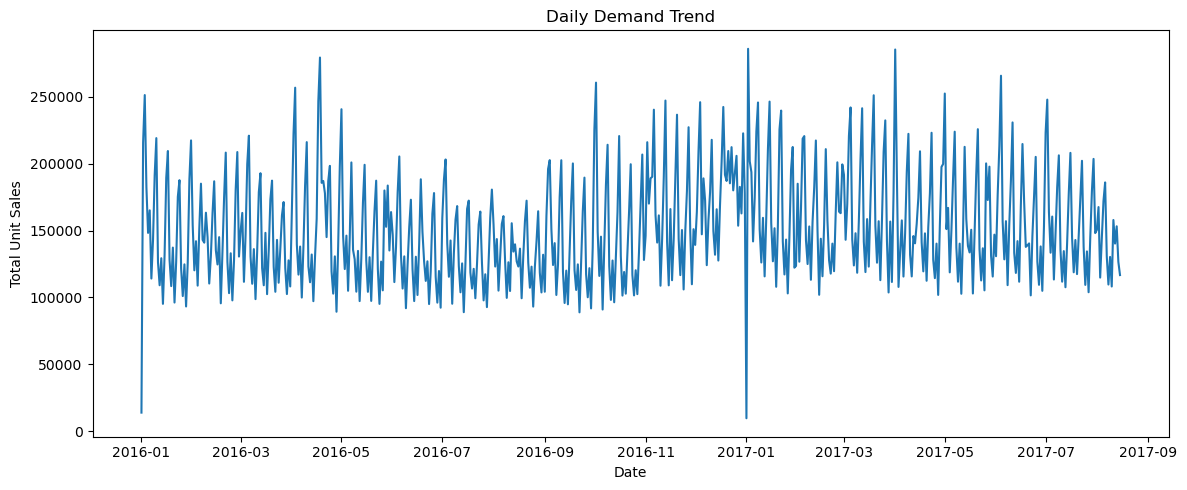

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(daily_demand["date"], daily_demand["unit_sales"])
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Unit Sales")
plt.tight_layout()
plt.show()

##### The daily demand trend shows short-term fluctuations in demand. This is useful for identifying spikes, drops, and periods of unstable demand.

### Demand by day of the week

In [23]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_demand = master.groupby("day_of_week")["unit_sales"].sum().reindex(day_order)

day_demand

day_of_week
Monday       1.203306e+07
Tuesday      1.034393e+07
Wednesday    1.224419e+07
Thursday     9.269225e+06
Friday       1.247827e+07
Saturday     1.577474e+07
Sunday       1.706697e+07
Name: unit_sales, dtype: float64

##### Demand was grouped by day of the week to understand weekly shopping patterns.

### Demand by day of the week

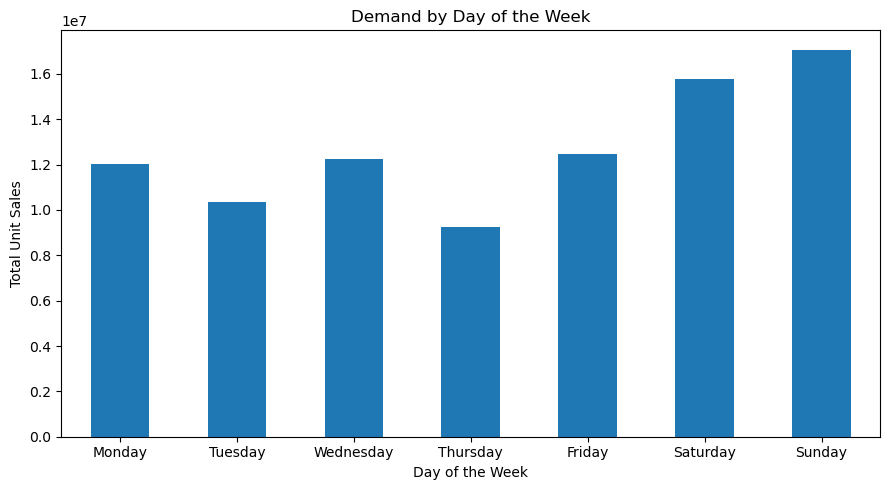

In [53]:
plt.figure(figsize=(9, 5))
day_demand.plot(kind="bar")
plt.title("Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart shows that `SUNDAY`  days of the week have higher demand. This can help with replenishment timing and store operations planning.

### Weekend vs weekday demand

In [25]:
weekend_demand = master.groupby("is_weekend")["unit_sales"].sum()

weekend_demand

is_weekend
False    5.636867e+07
True     3.284171e+07
Name: unit_sales, dtype: float64

Demand was compared between weekdays and weekends to understand whether shopping activity changes during weekends.

### Rename weekend labels for clarity

In [26]:
weekend_demand.index = weekend_demand.index.map({
    False: "Weekday",
    True: "Weekend"
})

weekend_demand


is_weekend
Weekday    5.636867e+07
Weekend    3.284171e+07
Name: unit_sales, dtype: float64

The weekend labels were renamed to make the output easier to understand.

### weekend vs weekday demand

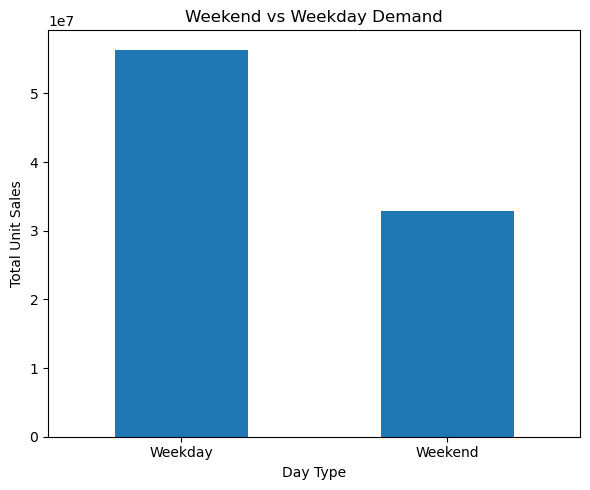

In [27]:
plt.figure(figsize=(6, 5))
weekend_demand.plot(kind="bar")
plt.title("Weekend vs Weekday Demand")
plt.xlabel("Day Type")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [49]:
weekend_daily = master.groupby(["date", "is_weekend"])["unit_sales"].sum().reset_index()

weekend_avg = weekend_daily.groupby("is_weekend")["unit_sales"].mean()

weekend_avg.index = weekend_avg.index.map({
    False: "Weekday",
    True: "Weekend"
})

weekend_avg

is_weekend
Weekday    133259.269686
Weekend    194329.671550
Name: unit_sales, dtype: float64

Average daily demand was calculated for weekends and weekdays to provide a fairer comparison than total demand, because there are more weekdays than weekend days.

This chart compares total demand during weekdays and weekends. This can support decisions on stock preparation before peak shopping periods.

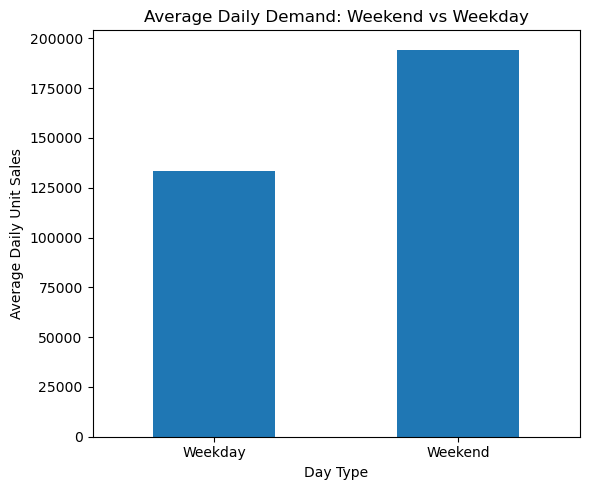

In [50]:
plt.figure(figsize=(6, 5))
weekend_avg.plot(kind="bar")
plt.title("Average Daily Demand: Weekend vs Weekday")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Weekend days have higher average daily demand than weekdays. This suggests that demand is stronger during weekends, so stores may need to prepare stock ahead of weekend shopping periods.

### Holiday vs non-holiday demand

In [28]:
holiday_demand = master.groupby("is_holiday")["unit_sales"].sum()

holiday_demand

is_holiday
False    7.412005e+07
True     1.509033e+07
Name: unit_sales, dtype: float64

Demand was grouped by holiday status to compare sales during holiday and non-holiday periods.

### Rename holiday labels

In [29]:
holiday_demand.index = holiday_demand.index.map({
    False: "Non-Holiday",
    True: "Holiday"
})

holiday_demand


is_holiday
Non-Holiday    7.412005e+07
Holiday        1.509033e+07
Name: unit_sales, dtype: float64

Holiday labels were renamed to make the comparison easier to read.

### holiday vs non-holiday demand

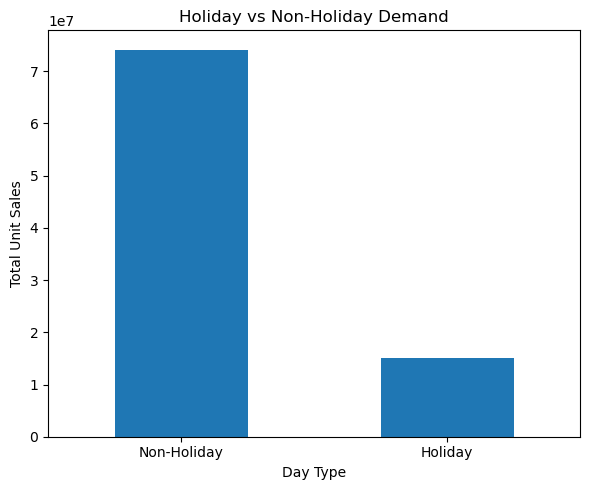

In [30]:
plt.figure(figsize=(6, 5))
holiday_demand.plot(kind="bar")
plt.title("Holiday vs Non-Holiday Demand")
plt.xlabel("Day Type")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The chart compares demand during holiday and non-holiday periods. This can help identify whether holidays are associated with higher or lower sales volume.

### Average daily demand for holiday vs non-holiday

In [31]:
holiday_daily = master.groupby(["date", "is_holiday"])["unit_sales"].sum().reset_index()

holiday_avg = holiday_daily.groupby("is_holiday")["unit_sales"].mean()

holiday_avg.index = holiday_avg.index.map({
    False: "Non-Holiday",
    True: "Holiday"
})

holiday_avg


is_holiday
Non-Holiday    148537.180299
Holiday        162261.640860
Name: unit_sales, dtype: float64

Average daily demand was calculated for holiday and non-holiday periods. This is a fairer comparison than total demand because there are usually more non-holiday days than holiday days.

### Average daily holiday demand

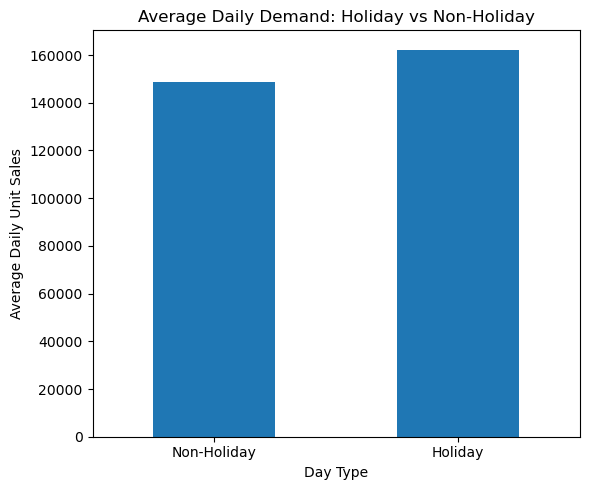

In [32]:
plt.figure(figsize=(6, 5))
holiday_avg.plot(kind="bar")
plt.title("Average Daily Demand: Holiday vs Non-Holiday")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart provides a fairer holiday comparison by showing average daily demand instead of total demand.

### Promotion vs non-promotion demand

In [33]:
promo_demand = master.groupby("onpromotion")["unit_sales"].sum()

promo_demand.index = promo_demand.index.map({
    False: "Not on Promotion",
    True: "On Promotion"
})

promo_demand

onpromotion
Not on Promotion    7.514237e+07
On Promotion        1.406801e+07
Name: unit_sales, dtype: float64

Demand was grouped by promotion status to compare sales volume for promoted and non-promoted products.

### promotion vs non-promotion demand

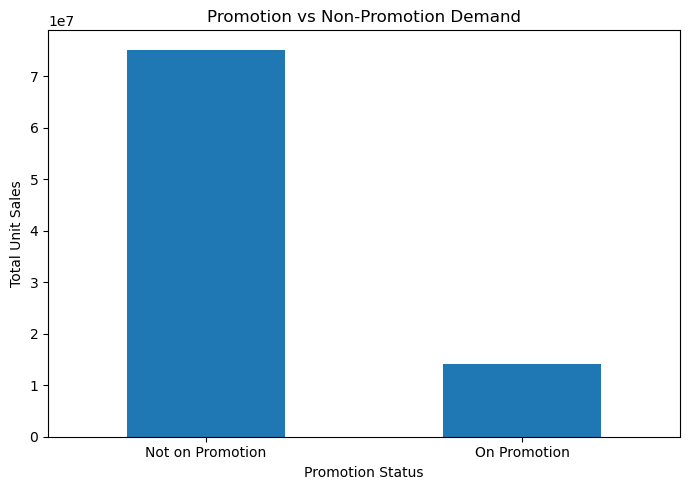

In [34]:
plt.figure(figsize=(7, 5))
promo_demand.plot(kind="bar")
plt.title("Promotion vs Non-Promotion Demand")
plt.xlabel("Promotion Status")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The chart compares total demand for promoted and non-promoted products. However, total demand may be influenced by the number of promoted and non-promoted records.

### Average demand per row by promotion status

In [35]:
promo_avg = master.groupby("onpromotion")["unit_sales"].mean()

promo_avg.index = promo_avg.index.map({
    False: "Not on Promotion",
    True: "On Promotion"
})

promo_avg


onpromotion
Not on Promotion    13.964036
On Promotion        25.993579
Name: unit_sales, dtype: float64

Average unit sales per record were calculated by promotion status. This provides a more balanced view of whether promoted products sell more per sales record.

### Average demand by promotion status

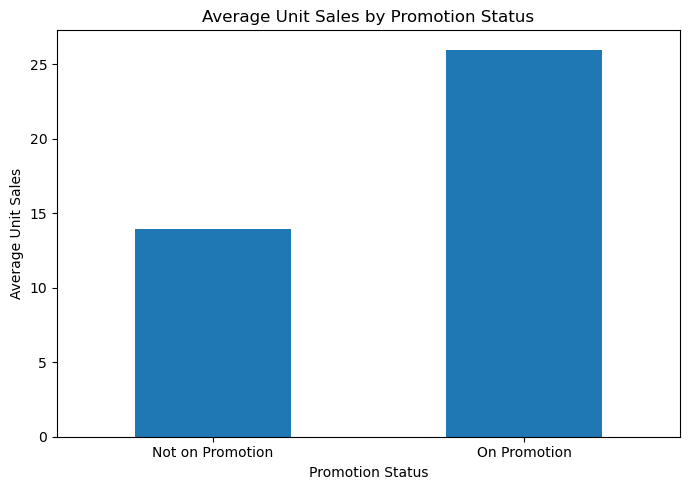

In [36]:
plt.figure(figsize=(7, 5))
promo_avg.plot(kind="bar")
plt.title("Average Unit Sales by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Average Unit Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart helps show whether items on promotion have higher average sales than items not on promotion.

### Store and product family demand table

In [37]:
store_family_demand = master.groupby(["store_nbr", "family"])["unit_sales"].sum().reset_index()

store_family_demand.head()


,store_nbr,family,unit_sales
0,25,BEVERAGES,1287268.000
1,25,BREAD/BAKERY,189786.451
2,25,CLEANING,265708.000
3,25,DAIRY,322872.000
4,25,GROCERY I,1043526.000


Demand was grouped by both store and product family to understand which categories perform best in each store.

### Pivot table for store-family demand

In [38]:
store_family_pivot = store_family_demand.pivot(
    index="family",
    columns="store_nbr",
    values="unit_sales"
)

store_family_pivot

store_nbr,25,44,45,47,49
family,,,,,
BEVERAGES,1287268.000,6129689.000,5565028.000,5162845.000,4470933.000
BREAD/BAKERY,189786.451,992843.248,787234.733,734913.261,777956.927
CLEANING,265708.000,1528944.000,1595889.000,1454493.000,1188017.000
DAIRY,322872.000,1684682.000,1477545.000,1429745.000,1493053.000
GROCERY I,1043526.000,6362273.000,6740239.354,6317761.000,4960570.000
MEATS,112681.500,573922.059,735639.684,570605.985,518748.144
POULTRY,93618.728,791421.567,826617.202,748305.246,651381.048
PRODUCE,883251.701,6055693.371,3998917.197,3717193.817,4968573.346


A pivot table was created to compare product family demand across stores. This structure is useful for heatmaps and Power BI reporting.

### Heatmap-style chart using Matplotlib

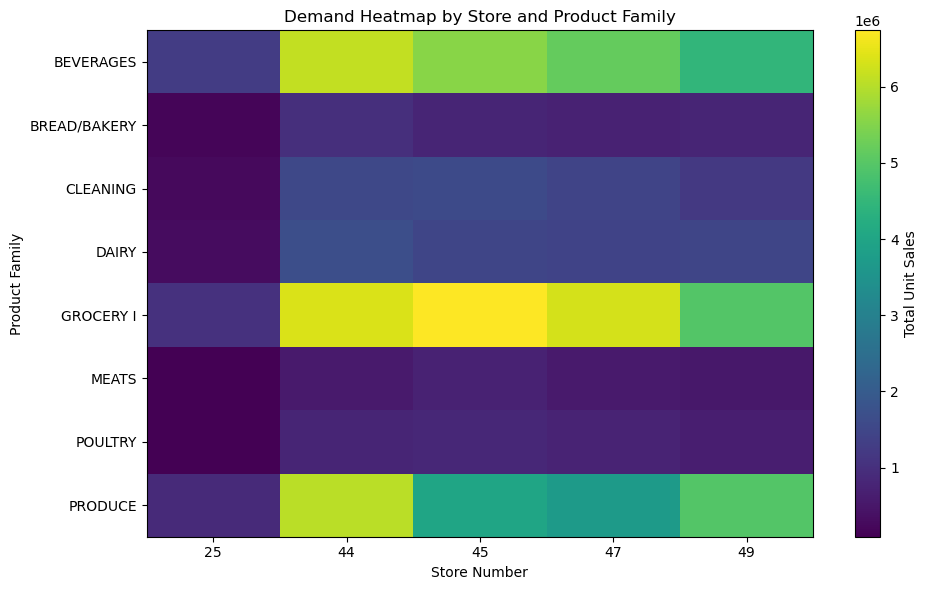

In [39]:
plt.figure(figsize=(10, 6))
plt.imshow(store_family_pivot, aspect="auto")
plt.colorbar(label="Total Unit Sales")
plt.xticks(range(len(store_family_pivot.columns)), store_family_pivot.columns)
plt.yticks(range(len(store_family_pivot.index)), store_family_pivot.index)
plt.title("Demand Heatmap by Store and Product Family")
plt.xlabel("Store Number")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

The heatmap shows demand concentration across stores and product families. Darker or stronger areas indicate higher demand and may require closer inventory attention.

### Fast-moving product families

In [40]:
fast_moving_families = family_demand.head(5)

fast_moving_families

family
GROCERY I    2.542437e+07
BEVERAGES    2.261576e+07
PRODUCE      1.962363e+07
DAIRY        6.407897e+06
CLEANING     6.033051e+06
Name: unit_sales, dtype: float64

The top five product families by demand were identified as fast-moving categories.

### Slow-moving product families

In [41]:
slow_moving_families = family_demand.tail(3)

slow_moving_families


family
BREAD/BAKERY    3482734.620
POULTRY         3111343.791
MEATS           2511597.372
Name: unit_sales, dtype: float64

The lowest-demand product families were identified as slow-moving categories. These categories may require careful inventory control to avoid overstocking.

### Demand variability by product family

In [42]:
family_variability = master.groupby("family")["unit_sales"].agg(["mean", "std"]).reset_index()

family_variability["coefficient_of_variation"] = (
    family_variability["std"] / family_variability["mean"]
)

family_variability = family_variability.sort_values(
    "coefficient_of_variation",
    ascending=False
)

family_variability


,family,mean,std,coefficient_of_variation
4,GROCERY I,10.773494,26.615202,2.470434
0,BEVERAGES,20.332029,47.373799,2.330008
7,PRODUCE,32.911306,56.883756,1.728396
2,CLEANING,7.574737,11.426484,1.508499
1,BREAD/BAKERY,13.233934,19.518863,1.474910
5,MEATS,18.068396,26.208384,1.450510
3,DAIRY,11.819199,14.605368,1.235732
6,POULTRY,27.518187,33.821016,1.229042


Demand variability was calculated using the coefficient of variation. A higher value means demand is less stable relative to its average level.

### demand variability by family

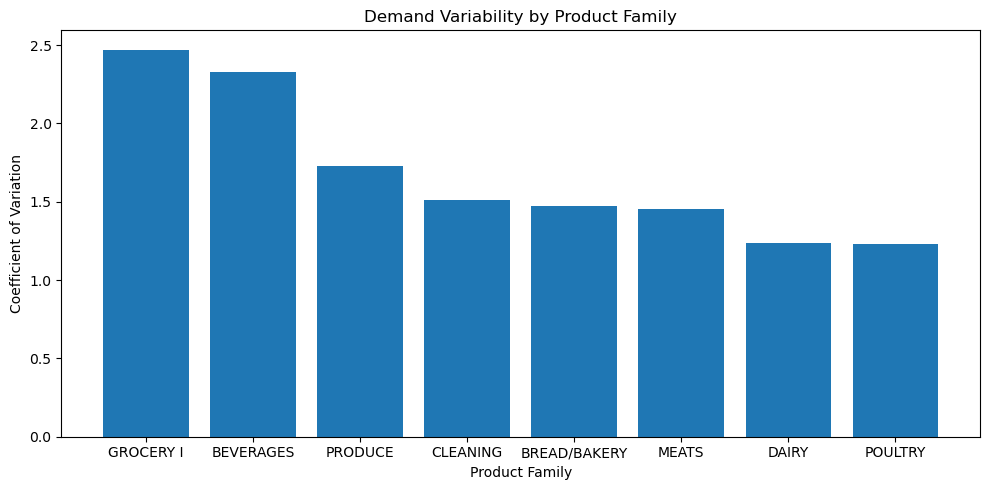

In [54]:
plt.figure(figsize=(10, 5))
plt.bar(
    family_variability["family"],
    family_variability["coefficient_of_variation"]
)
plt.title("Demand Variability by Product Family")
plt.xlabel("Product Family")
plt.ylabel("Coefficient of Variation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The chart shows that `GROCERY I` has the highest demand variability among the selected product families.

### Demand variability by store

In [44]:
store_variability = master.groupby("store_nbr")["unit_sales"].agg(["mean", "std"]).reset_index()

store_variability["coefficient_of_variation"] = (
    store_variability["std"] / store_variability["mean"]
)

store_variability = store_variability.sort_values(
    "coefficient_of_variation",
    ascending=False
)

store_variability

,store_nbr,mean,std,coefficient_of_variation
2,45,16.559363,41.713758,2.519044
1,44,18.380757,40.277162,2.191268
0,25,5.777175,12.479564,2.160150
3,47,15.533095,31.693554,2.040389
4,49,14.925310,28.954966,1.939991


Demand variability was calculated by store to identify stores with less stable demand patterns

### Demand variability by store

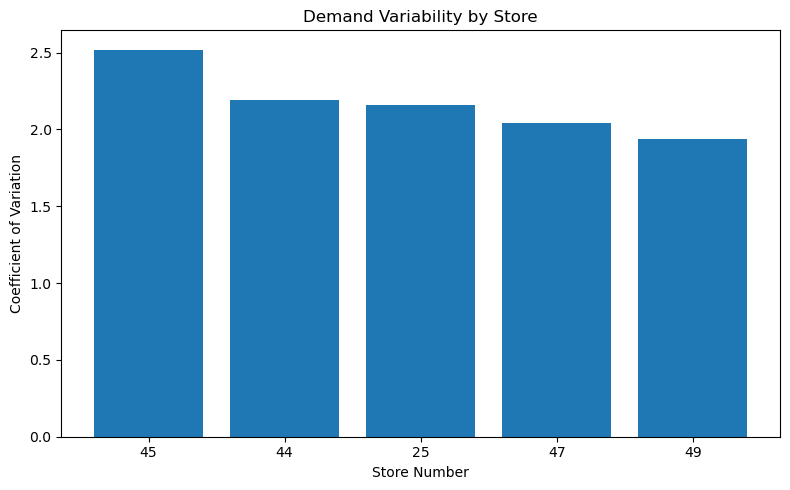

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(
    store_variability["store_nbr"].astype(str),
    store_variability["coefficient_of_variation"]
)
plt.title("Demand Variability by Store")
plt.xlabel("Store Number")
plt.ylabel("Coefficient of Variation")
plt.tight_layout()
plt.show()

Stores with higher demand variability may require more careful replenishment planning because their demand is less predictable.

### Top items by demand

In [46]:
top_items = master.groupby(["item_nbr", "family"])["unit_sales"].sum().reset_index()

top_items = top_items.sort_values("unit_sales", ascending=False)

top_items.head(10)

,item_nbr,family,unit_sales
2034,1503844,PRODUCE,1275497.253
1970,1473474,PRODUCE,859210.260
1090,1047679,BEVERAGES,572087.000
1866,1463993,BEVERAGES,531245.000
2063,1642399,PRODUCE,526058.092
1727,1430040,BEVERAGES,515323.000
1865,1463992,BEVERAGES,498960.000
2107,1695835,PRODUCE,463371.330
2035,1503847,PRODUCE,394792.942
324,364738,BEVERAGES,373746.000


The top-selling individual items were identified. These items can be important candidates for ABC classification and inventory prioritization.

### Slow-moving items

In [47]:
slow_items = top_items.sort_values("unit_sales", ascending=True)

slow_items.head(10)

,item_nbr,family,unit_sales
1191,1091338,MEATS,0.134
580,584129,MEATS,0.974
2743,2033554,PRODUCE,1.000
2895,2126944,BEVERAGES,1.000
1438,1239843,DAIRY,1.000
1323,1161046,GROCERY I,1.000
570,583977,MEATS,1.000
708,760319,POULTRY,1.541
2889,2123747,GROCERY I,2.000
2886,2123463,GROCERY I,2.000


The lowest-demand items were identified. These items may be reviewed for slow movement, low replenishment priority, or possible overstock risk.
This does not mean the items are bad. It only means they have low sales within my selected scope.

### Saving useful EDA output tables

In [48]:
family_demand.to_csv(folder + r"\eda_family_demand.csv")
store_demand.to_csv(folder + r"\eda_store_demand.csv")
daily_demand.to_csv(folder + r"\eda_daily_demand.csv", index=False)
family_variability.to_csv(folder + r"\eda_family_variability.csv", index=False)
store_variability.to_csv(folder + r"\eda_store_variability.csv", index=False)
top_items.to_csv(folder + r"\eda_top_items.csv", index=False)

## Final EDA Summary

This exploratory analysis showed that demand is not evenly distributed across the selected product families and stores.

Key findings:

1. Total demand across the selected scope was 89,210,385.57 unit sales.
2. The selected stores recorded 9,347,180 transactions after correcting for duplicated transaction rows.
3. `GROCERY I` was the highest-demand product family.
4. Store 44 generated the highest total demand among the selected stores.
5. The top three product families — `GROCERY I`, `BEVERAGES`, and `PRODUCE` — contributed 75.85% of total demand.
6. Weekend days had higher average daily demand than weekdays.
7. Holiday impact was evaluated using average daily demand rather than total demand to avoid misleading comparisons.
8. Promotion impact was also evaluated using average sales per record instead of only total sales.
9. Product families with higher demand variability may require closer replenishment monitoring.
10. Since the dataset does not include inventory-on-hand values, future stockout-related analysis will be framed as potential replenishment risk rather than confirmed stockouts.

## Conclusion

The EDA confirms that demand is concentrated in a few major product families and varies across stores, weekends, holidays, and promotion periods.

These findings support the next stage of the project, where demand forecasting will be used to estimate future demand patterns for selected high-priority product families.